In [1]:
# Import Libraries
# ===============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


In [11]:
# Load Dataset
boston=pd.read_csv("BostonHousing.csv")
boston

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [15]:
try:
    boston = load_boston()
    X = boston.data
    y = boston.target
    feature_names = boston.feature_names
except:
    from sklearn.datasets import fetch_openml
    boston = fetch_openml(name="boston", version=1, as_frame=True)
    X = boston.data
    y = boston.target.astype(float)
    feature_names = X.columns

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['PRICE'] = y


In [17]:
print(df.head())

      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  PRICE  
0  396.90   4.98   24.0  
1  396.90   9.14   21.6  
2  392.83   4.03   34.7  
3  394.63   2.94   33.4  
4  396.90   5.33   36.2  


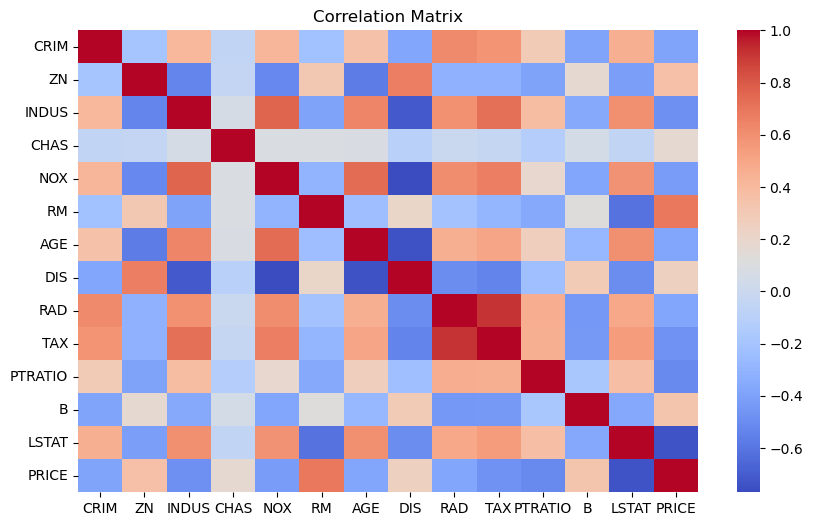

In [19]:
# Data Visualization
# ===============================================================
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [23]:
# Split Dataset
# ===============================================================
X = df.drop("PRICE", axis=1)
y = df["PRICE"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [25]:
# Feature Scaling
# ===============================================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [27]:
# Build Deep Neural Network Model
# ===============================================================
model = Sequential()

# Input + Hidden Layers
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))

# Output Layer for Regression
model.add(Dense(1))

# Compile Model
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mae']
)

# Model Summary
model.summary()


C:\Users\Varad\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Train Model
# ===============================================================
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    verbose=1)


Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 289.4093 - mae: 13.8857 - val_loss: 39.2693 - val_mae: 4.4550
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 31.2936 - mae: 4.1131 - val_loss: 35.2668 - val_mae: 4.2127
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 20.8756 - mae: 3.3627 - val_loss: 21.9384 - val_mae: 3.2269
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 14.8708 - mae: 2.9221 - val_loss: 23.2633 - val_mae: 3.5865
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 15.7604 - mae: 2.9741 - val_loss: 17.9319 - val_mae: 3.0118
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 12.6021 - mae: 2.6938 - val_loss: 17.7107 - val_mae: 2.9346
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12.2982 - mae: 2.6433 - val_loss: 17.5787 - val_mae: 3.0635
Epoch 8/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 11.3216 - mae: 2.5191 - val_loss: 16.2239 - val_mae: 2.9467
Epoch 9/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 

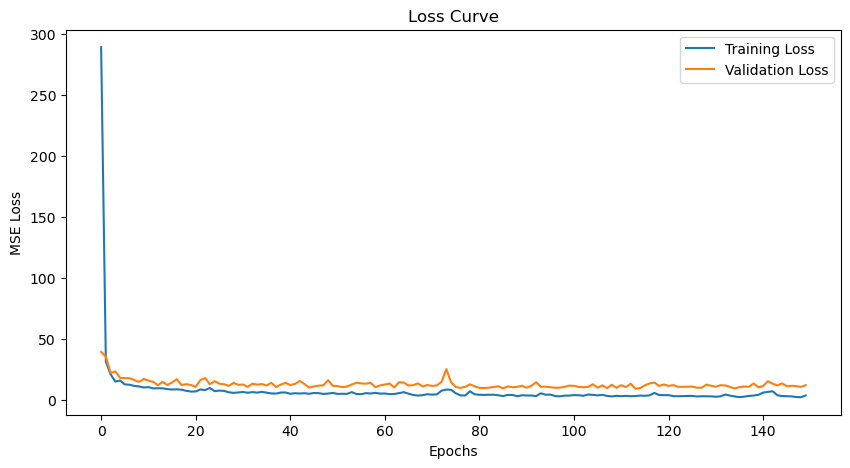

In [31]:
# Plot Loss Graph

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()





In [33]:
# Prediction

y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [35]:
# Performance Evaluation
# ===============================================================
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2 Score:", r2)



Model Performance:
MSE : 10.66779395520743
RMSE: 3.2661588992587958
MAE : 2.1566416805865716
R2 Score: 0.8545309747366312


   Actual Price  Predicted Price
0          23.6        27.781813
1          32.4        34.103901
2          13.6        14.029517
3          22.8        23.395624
4          16.1        15.282536
5          20.0        19.282995
6          17.8        17.943626
7          14.0        13.141349
8          19.6        22.977785
9          16.8        21.581713


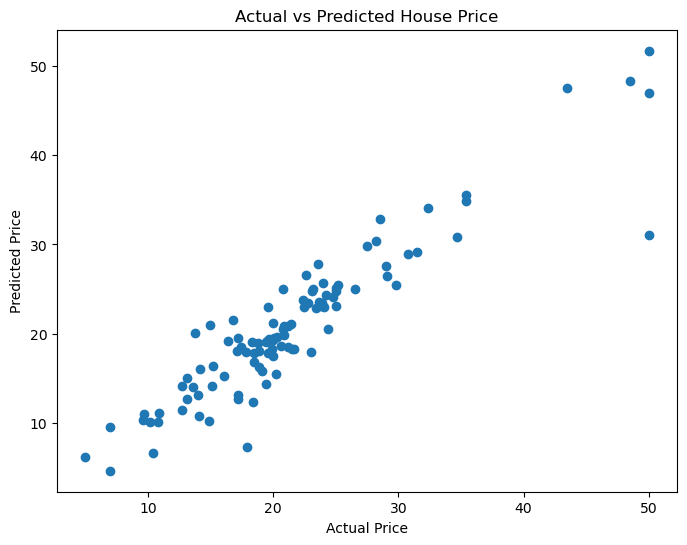

In [37]:
# Compare Actual vs Predicted
# ===============================================================
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred.flatten()
})

print(results.head(10))

# ===============================================================
# Scatter Plot
# ===============================================================
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()



   Actual Price  Predicted Price
0          23.6        27.781813
1          32.4        34.103901
2          13.6        14.029517
3          22.8        23.395624
4          16.1        15.282536
5          20.0        19.282995
6          17.8        17.943626
7          14.0        13.141349
8          19.6        22.977785
9          16.8        21.581713


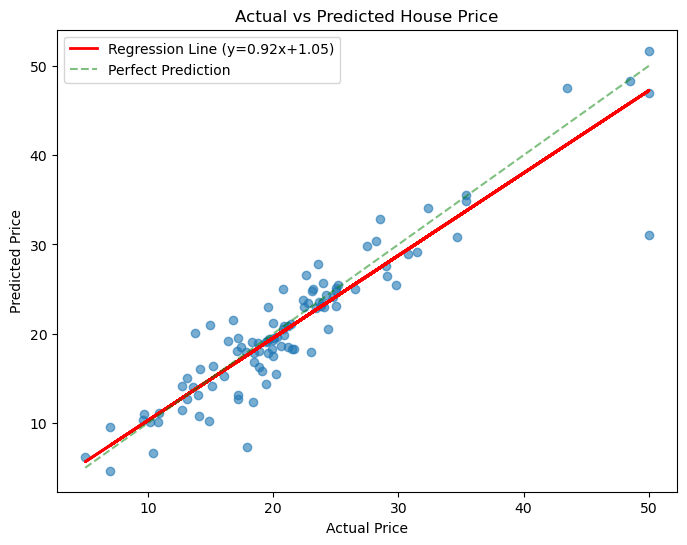


Regression Line: y = 0.9236x + 1.0507
Slope: 0.9236 (ideal = 1.0)
Intercept: 1.0507 (ideal = 0.0)


In [43]:
# Compare Actual vs Predicted
# ===============================================================
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred.flatten()
})

print(results.head(10))

# ===============================================================
# Scatter Plot with Regression Line
# ===============================================================
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)

# Add regression line
m, b = np.polyfit(y_test.values.flatten(), y_pred.flatten(), 1)
plt.plot(y_test, m * y_test + b, color='red', linewidth=2, label=f'Regression Line (y={m:.2f}x+{b:.2f})')

# Add perfect prediction line (optional, for reference)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'g--', alpha=0.5, label='Perfect Prediction')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.legend()
plt.show()

# Print regression statistics
print(f"\nRegression Line: y = {m:.4f}x + {b:.4f}")
print(f"Slope: {m:.4f} (ideal = 1.0)")
print(f"Intercept: {b:.4f} (ideal = 0.0)")